# Arrival Probability × Service-Time Variation

**Research question:** Does service-time variability have a larger effect on passenger waiting time when arrival demand is close to nominal service capacity?

This full-factorial experiment crosses three arrival probabilities with three service-time distributions: nine combinations, each repeated with 30 seeds for 5,000 steps (270 runs). It complements the four single-factor studies. All combinations are rerun here so this notebook can run independently.

## Experimental Design

| Factor or control | Settings |
| --- | --- |
| Arrival probability | 0.30, 0.40, 0.48 per step |
| Service-time variation | 0 (fixed 4), 1 (uniform integers 3–5), 3 (uniform integers 1–7) |
| Expected service duration | 4 steps for every distribution |
| Checkpoints | 2 |
| Internal waiting capacity | 10 passengers per checkpoint, excluding service |
| Observation length | 5,000 steps from an empty system |
| Repetitions | Seeds 0–29 per combination |

Nominal service capacity is 2 / 4 = 0.5 passengers per step. The nominal load ratios are 0.60, 0.80, and 0.96. All tested demands are below nominal capacity; 0.48 is near capacity, not a critical-load or overloaded setting. A load ratio below one alone does not verify that these finite observations represent steady state.

The same seed list makes the study reproducible, but the shared model uses one random generator for arrival and service draws. Changing service variation does **not** guarantee matching arrival sequences. Comparisons are descriptive, without a paired significance test or a claim of statistically significant interaction.

## Setup

Use the project environment from `requirements.txt`. Start from the project root or `notebooks`, restart the kernel, and run all cells. The final cell writes three result CSV files to `data/arrival_variation/`, replacing earlier exports from this notebook.

In [1]:
import csv
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "model.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Start from the project root or its notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import AirportSecurityModel

arrival_rates = [0.30, 0.40, 0.48]
variations = {"Fixed": 0, "Low variation": 1, "High variation": 3}
seeds = range(30)
base_parameters = {
    "queue_capacity": 10,
    "num_checkpoints": 2,
    "processing_time": 4,
    "simulation_steps": 5000,
}
nominal_capacity = base_parameters["num_checkpoints"] / base_parameters["processing_time"]

## Measurements and Validation

Waiting time includes internal and external waiting, but its mean covers only passengers who complete screening within the observation period. A run with no completions has an undefined waiting mean (`NaN`), not zero. Queue lengths are time averages; throughput is completions per step; unfinished counts and fractions are measured at the end. The observed service-duration mean covers everyone who started service, including those still in service at the end.

No warm-up is excluded and no drain-down is added. Read waiting, external queues, and unfinished counts together, especially at arrival probability 0.48. The checks below verify passenger conservation, unique membership, internal queue bounds at the end, and the timing of completed services.

In [2]:
experiment_results = []

for arrival_rate in arrival_rates:
    for scenario, variation in variations.items():
        for seed in seeds:
            model = AirportSecurityModel(
                **base_parameters,
                arrival_rate=arrival_rate,
                processing_time_variation=variation,
                seed=seed,
            )
            model.run()
            remaining = (
                list(model.external_waiting)
                + [passenger for queue in model.queues for passenger in queue]
                + [passenger for passenger in model.in_service if passenger is not None]
            )
            completed = model.completed_passengers
            assert len(model.all_passengers) == len(completed) + len(remaining)
            assert len({p.id for p in completed + remaining}) == len(model.all_passengers)
            assert all(len(queue) <= model.queue_capacity for queue in model.queues)
            assert all(
                p.arrival_time <= p.queue_entry_time <= p.service_start_time
                and p.completion_time - p.service_start_time == p.processing_time
                and p.waiting_time == p.service_start_time - p.arrival_time
                for p in completed
            )
            durations = [p.processing_time for p in model.all_passengers
                         if p.processing_time is not None]
            assert all(4 - variation <= duration <= 4 + variation for duration in durations)
            waits = [p.waiting_time for p in completed]
            experiment_results.append({
                **base_parameters,
                "arrival_rate": arrival_rate,
                "scenario": scenario,
                "processing_time_variation": variation,
                "nominal_load_ratio": arrival_rate / nominal_capacity,
                "seed": seed,
                "arrived_passengers": len(model.all_passengers),
                "completed_passengers": len(completed),
                "mean_completed_wait": float(np.mean(waits)) if waits else np.nan,
                "mean_internal_queue": float(np.mean(model.queue_length_history)),
                "mean_external_queue": float(np.mean(model.external_waiting_history)),
                "throughput_rate": len(completed) / model.simulation_steps,
                "unfinished_passengers": len(remaining),
                "unfinished_fraction": (len(remaining) / len(model.all_passengers)
                                        if model.all_passengers else np.nan),
                "observed_mean_service_duration": (float(np.mean(durations))
                                                   if durations else np.nan),
            })

expected_runs = len(arrival_rates) * len(variations) * len(seeds)
assert len(experiment_results) == expected_runs
assert len({(r["arrival_rate"], r["processing_time_variation"], r["seed"])
            for r in experiment_results}) == expected_runs
print(f"Completed {expected_runs} simulation runs; all validation checks passed.")

Completed 270 simulation runs; all validation checks passed.


## Summary Across Runs

Each run has equal weight. Waiting error bars show one sample standard deviation **between run means**, not passenger-level dispersion or confidence intervals. Undefined run means are excluded and their valid count is reported. Other plotted measures show means only. The theoretical service mean is 4, but the observed mean need not be exactly 4 in a finite sample.

In [3]:
summary_results = []

for arrival_rate in arrival_rates:
    for scenario, variation in variations.items():
        runs = [r for r in experiment_results
                if r["arrival_rate"] == arrival_rate and r["scenario"] == scenario]
        waits = np.array([r["mean_completed_wait"] for r in runs])
        valid_waits = waits[np.isfinite(waits)]
        row = {
            "arrival_rate": arrival_rate,
            "scenario": scenario,
            "processing_time_variation": variation,
            "nominal_load_ratio": arrival_rate / nominal_capacity,
            "runs": len(runs),
            "valid_wait_runs": len(valid_waits),
            "mean_wait": float(np.mean(valid_waits)) if len(valid_waits) else np.nan,
            "sd_wait": float(np.std(valid_waits, ddof=1)) if len(valid_waits) > 1 else np.nan,
        }
        for metric in ["mean_internal_queue", "mean_external_queue", "throughput_rate",
                       "unfinished_passengers", "unfinished_fraction",
                       "observed_mean_service_duration"]:
            values = np.array([r[metric] for r in runs], dtype=float)
            valid = values[np.isfinite(values)]
            row[metric] = float(np.mean(valid)) if len(valid) else np.nan
        summary_results.append(row)

summary_lookup = {(r["arrival_rate"], r["scenario"]): r for r in summary_results}
print("Arrival  Scenario         Valid    Wait     SD    Internal  External  Throughput  Unfinished")
for r in summary_results:
    print(f"{r['arrival_rate']:.2f}     {r['scenario']:<15}  "
          f"{r['valid_wait_runs']:2}/{r['runs']:<2}  "
          f"{r['mean_wait']:7.3f} {r['sd_wait']:6.3f}  "
          f"{r['mean_internal_queue']:8.3f} {r['mean_external_queue']:8.3f}  "
          f"{r['throughput_rate']:10.4f} {r['unfinished_passengers']:10.2f}")

Arrival  Scenario         Valid    Wait     SD    Internal  External  Throughput  Unfinished
0.30     Fixed            30/30    0.675  0.077     0.203    0.000      0.2999       1.43
0.30     Low variation    30/30    0.747  0.073     0.225    0.000      0.3010       1.40
0.30     High variation   30/30    1.021  0.115     0.308    0.000      0.3010       1.60
0.40     Fixed            30/30    1.962  0.253     0.785    0.000      0.3990       2.37
0.40     Low variation    30/30    2.122  0.311     0.849    0.000      0.3991       1.87
0.40     High variation   30/30    2.905  0.513     1.161    0.000      0.3987       2.43
0.48     Fixed            30/30   10.667  4.871     4.939    0.199      0.4774       8.00
0.48     Low variation    30/30   11.382  5.260     5.309    0.158      0.4774       6.07
0.48     High variation   30/30   15.323  7.745     6.692    0.655      0.4768      10.03


## Interaction: Does the Variability Penalty Change with Demand?

The left panel plots waiting against arrival probability for each service distribution. The right panel shows the difference between each variable-service mean and the fixed-service mean at the same arrival probability. A changing gap is a descriptive interaction on the additive waiting-time scale. Connecting lines guide the eye between tested settings; they do not establish the curve at untested settings. Gap estimates have no uncertainty bars and are not significance tests.

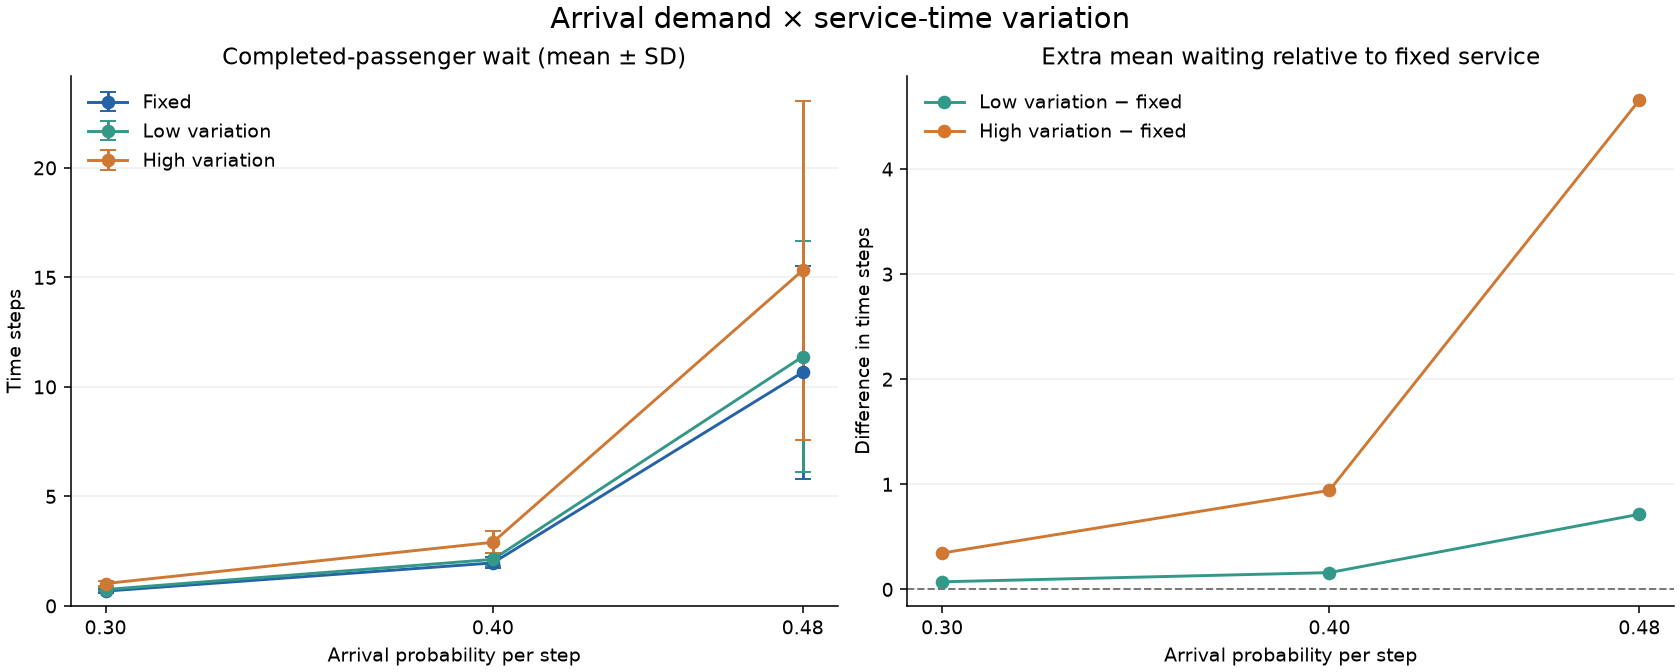

Arrival  Low − fixed  High − fixed (time steps)
0.30           0.073         0.346
0.40           0.160         0.943
0.48           0.715         4.656
Change in the high-minus-fixed gap from 0.30 to 0.48: 4.309 steps.
The observed high-variation waiting penalty is larger at the highest demand.
These contrasts are descriptive; statistical significance has not been established.


In [4]:
contrast_results = []
for arrival_rate in arrival_rates:
    fixed_wait = summary_lookup[(arrival_rate, "Fixed")]["mean_wait"]
    contrast_results.append({
        "arrival_rate": arrival_rate,
        "low_minus_fixed_wait": summary_lookup[(arrival_rate, "Low variation")]["mean_wait"] - fixed_wait,
        "high_minus_fixed_wait": summary_lookup[(arrival_rate, "High variation")]["mean_wait"] - fixed_wait,
    })

colors = {"Fixed": "#2563A6", "Low variation": "#349889", "High variation": "#CE7833"}
with plt.rc_context({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False}):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
    fig.suptitle("Arrival demand × service-time variation", fontsize=15)
    for scenario in variations:
        rows = [summary_lookup[(p, scenario)] for p in arrival_rates]
        axes[0].errorbar(arrival_rates, [r["mean_wait"] for r in rows],
                         yerr=[r["sd_wait"] for r in rows], marker="o", capsize=4,
                         label=scenario, color=colors[scenario])
    axes[0].set(title="Completed-passenger wait (mean ± SD)", ylabel="Time steps")
    axes[0].set_ylim(bottom=0)
    axes[0].legend(frameon=False)
    for scenario, key in [("Low variation", "low_minus_fixed_wait"),
                          ("High variation", "high_minus_fixed_wait")]:
        axes[1].plot(arrival_rates, [r[key] for r in contrast_results], marker="o",
                     color=colors[scenario], label=f"{scenario} − fixed")
    axes[1].axhline(0, color="#777777", linestyle="--", linewidth=1)
    axes[1].set(title="Extra mean waiting relative to fixed service", ylabel="Difference in time steps")
    axes[1].legend(frameon=False)
    for ax in axes:
        ax.set_xlabel("Arrival probability per step")
        ax.set_xticks(arrival_rates)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
    plt.show()

print("Arrival  Low − fixed  High − fixed (time steps)")
for r in contrast_results:
    print(f"{r['arrival_rate']:.2f}     {r['low_minus_fixed_wait']:11.3f}  {r['high_minus_fixed_wait']:12.3f}")
change_in_gap = (contrast_results[-1]["high_minus_fixed_wait"]
                 - contrast_results[0]["high_minus_fixed_wait"])
print(f"Change in the high-minus-fixed gap from {arrival_rates[0]:.2f} to "
      f"{arrival_rates[-1]:.2f}: {change_in_gap:.3f} steps.")
if np.isfinite(change_in_gap):
    direction = "larger" if change_in_gap > 0 else "smaller" if change_in_gap < 0 else "unchanged"
    print(f"The observed high-variation waiting penalty is {direction} at the highest demand.")
print("These contrasts are descriptive; statistical significance has not been established.")

## Queues, Throughput, and Unfinished Passengers

Panels show run means without error bars and have separate vertical scales. Internal queues are bounded; external waiting is unbounded. Throughput near arrival demand does not imply negligible waiting or establish steady state. Unfinished counts include external waiters, internal waiters, and passengers still in service.

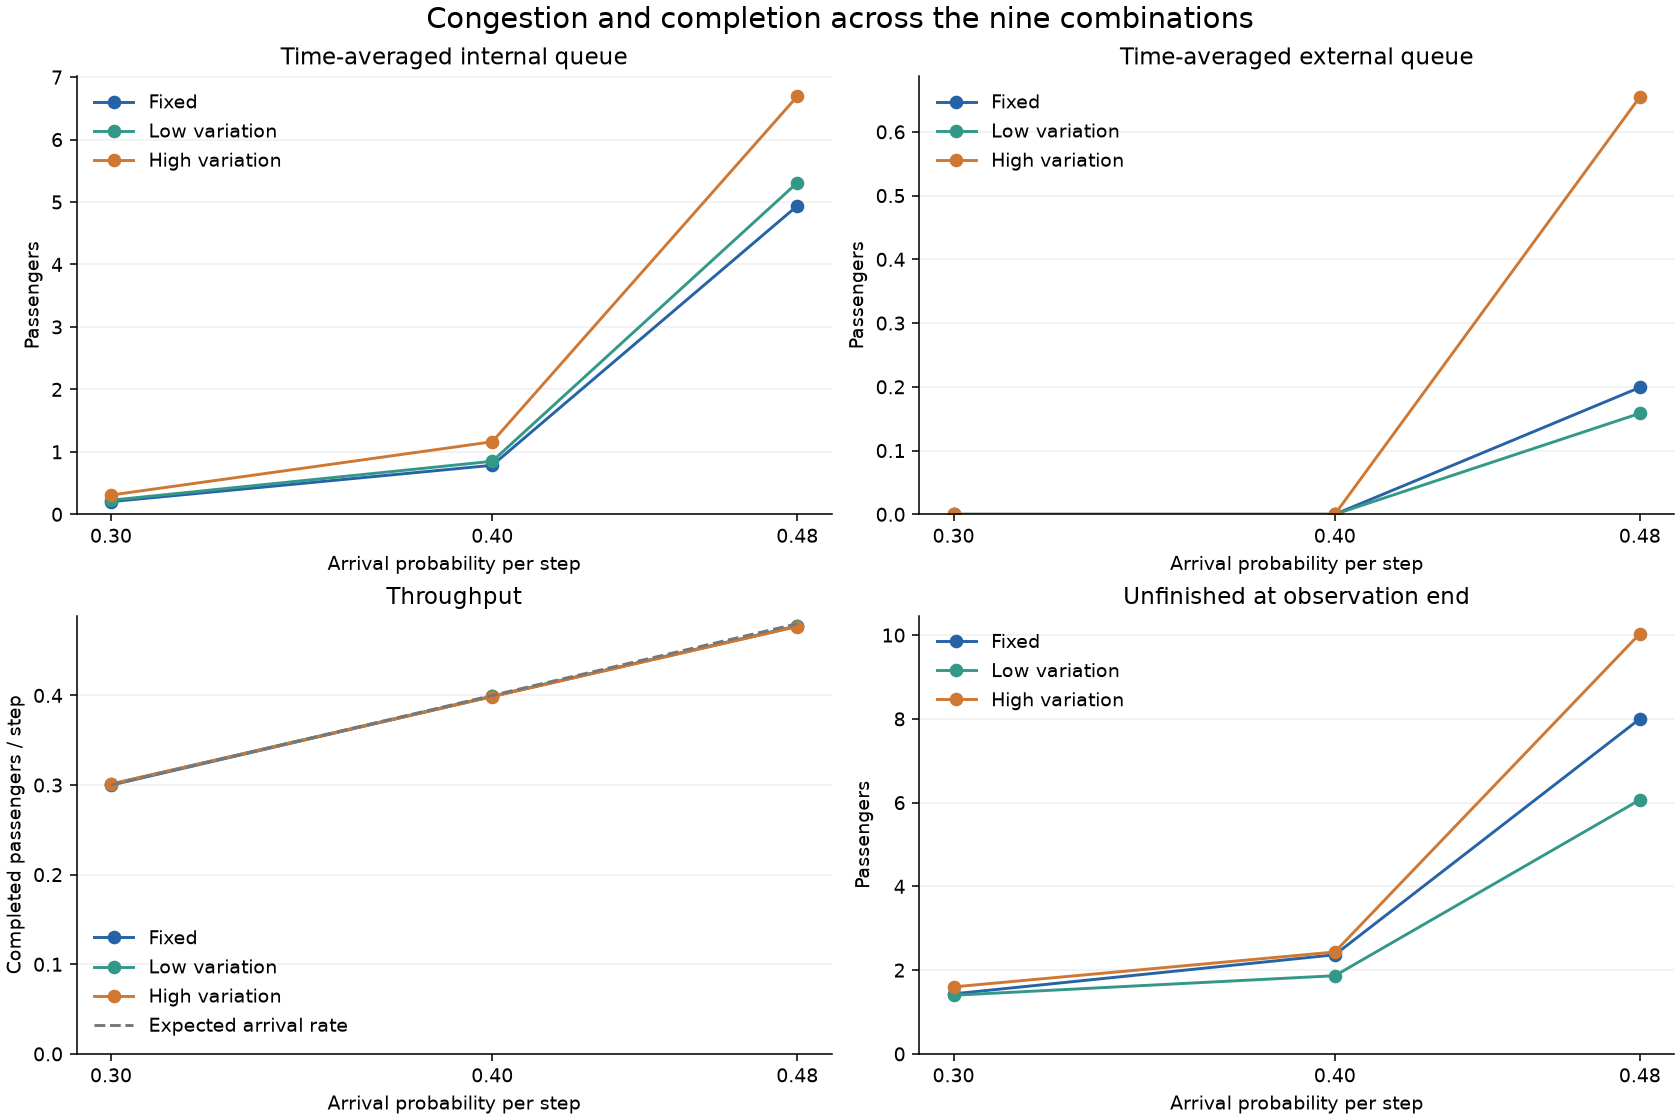

In [5]:
panels = [
    ("mean_internal_queue", "Time-averaged internal queue", "Passengers"),
    ("mean_external_queue", "Time-averaged external queue", "Passengers"),
    ("throughput_rate", "Throughput", "Completed passengers / step"),
    ("unfinished_passengers", "Unfinished at observation end", "Passengers"),
]
with plt.rc_context({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    fig.suptitle("Congestion and completion across the nine combinations", fontsize=15)
    for ax, (metric, title, unit) in zip(axes.flat, panels):
        for scenario in variations:
            values = [summary_lookup[(p, scenario)][metric] for p in arrival_rates]
            ax.plot(arrival_rates, values, marker="o", color=colors[scenario], label=scenario)
        if metric == "throughput_rate":
            ax.plot(arrival_rates, arrival_rates, linestyle="--", color="#777777",
                    label="Expected arrival rate")
        ax.set(title=title, xlabel="Arrival probability per step", ylabel=unit)
        ax.set_xticks(arrival_rates)
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
        ax.legend(frameon=False)
    plt.show()

## Interpretation and Limitations

In the saved default run, fixed-service mean waiting rises from 0.675 to 10.667 steps between arrival probabilities 0.30 and 0.48. High-variation waiting rises from 1.021 to 15.323. The high-minus-fixed gap therefore grows from 0.346 to 4.656 steps. This supports the descriptive finding that the absolute waiting penalty of service variability is larger near capacity in the tested settings. Update this paragraph if the parameters or saved results change; the numerical contrasts above regenerate automatically.

- Compare the variability penalties across demand levels, not just the individual scenario means. An increasing gap supports a descriptive interaction in these finite-horizon experiments; it does not establish a statistically significant interaction or a general law for real airports.
- All service distributions have theoretical mean 4, but sampled service means can differ. Arrival sequences are not guaranteed to match across variation settings even with the same seed. Separating arrival and service random streams would support more controlled comparisons in future work.
- All observations start empty and include the initial transient. At nominal load 0.96, observation-length sensitivity is particularly important. No steady-state convergence has been demonstrated.
- Completed-only waiting can omit passengers experiencing long waits at the observation boundary. Read it alongside external queues and unfinished counts and fractions. Similar throughput is compatible with different waiting times.
- The three arrival settings do not test equality with nominal capacity (0.5) or overload. Those regimes must be distinguished from the near-capacity setting used here.
- These controls isolate arrival probability and service-duration variation within this model. They do not test changes in average service duration, queue switching, abandonment, or real-airport calibration.

## Export Reusable Results

The files below contain all run-level results, nine scenario summaries, and three descriptive waiting contrasts. Re-running this cell updates the exports to match the current notebook parameters. Saved figures and text above are generated from these same results.

In [6]:
export_dir = project_root / "data" / "arrival_variation"
export_dir.mkdir(parents=True, exist_ok=True)
for filename, rows in [
    ("runs.csv", experiment_results),
    ("summary.csv", summary_results),
    ("contrasts.csv", contrast_results),
]:
    with (export_dir / filename).open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {len(rows)} rows to data/arrival_variation/{filename}")

Saved 270 rows to data/arrival_variation/runs.csv
Saved 9 rows to data/arrival_variation/summary.csv
Saved 3 rows to data/arrival_variation/contrasts.csv
